In [1]:
import pandas_datareader.data as pdr
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import pandas_datareader.data as pdr

ff = pdr.DataReader('F-F_Research_Data_Factors', 'famafrench', start='1926-01-01')
df = ff[0]

/tmp/ipykernel_3794/275482877.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = pdr.DataReader('F-F_Research_Data_Factors', 'famafrench', start='1926-01-01')
/tmp/ipykernel_3794/275482877.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff = pdr.DataReader('F-F_Research_Data_Factors', 'famafrench', start='1926-01-01')


In [3]:
df = ff[0]
df.head()
df.index = df.index.to_timestamp()
df.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
1926-07-01,2.89,-2.55,-2.39,0.22
1926-08-01,2.64,-1.14,3.81,0.25
1926-09-01,0.38,-1.36,0.05,0.23
1926-10-01,-3.27,-0.14,0.82,0.32
1926-11-01,2.54,-0.11,-0.61,0.31


In [4]:
df.head(20)

,Mkt-RF,SMB,HML,RF
Date,,,,
1926-07-01,2.89,-2.55,-2.39,0.22
1926-08-01,2.64,-1.14,3.81,0.25
1926-09-01,0.38,-1.36,0.05,0.23
1926-10-01,-3.27,-0.14,0.82,0.32
1926-11-01,2.54,-0.11,-0.61,0.31
1926-12-01,2.62,-0.07,0.06,0.28
1927-01-01,-0.05,-0.32,4.58,0.25
1927-02-01,4.17,0.07,2.72,0.26
1927-03-01,0.14,-1.77,-2.38,0.30


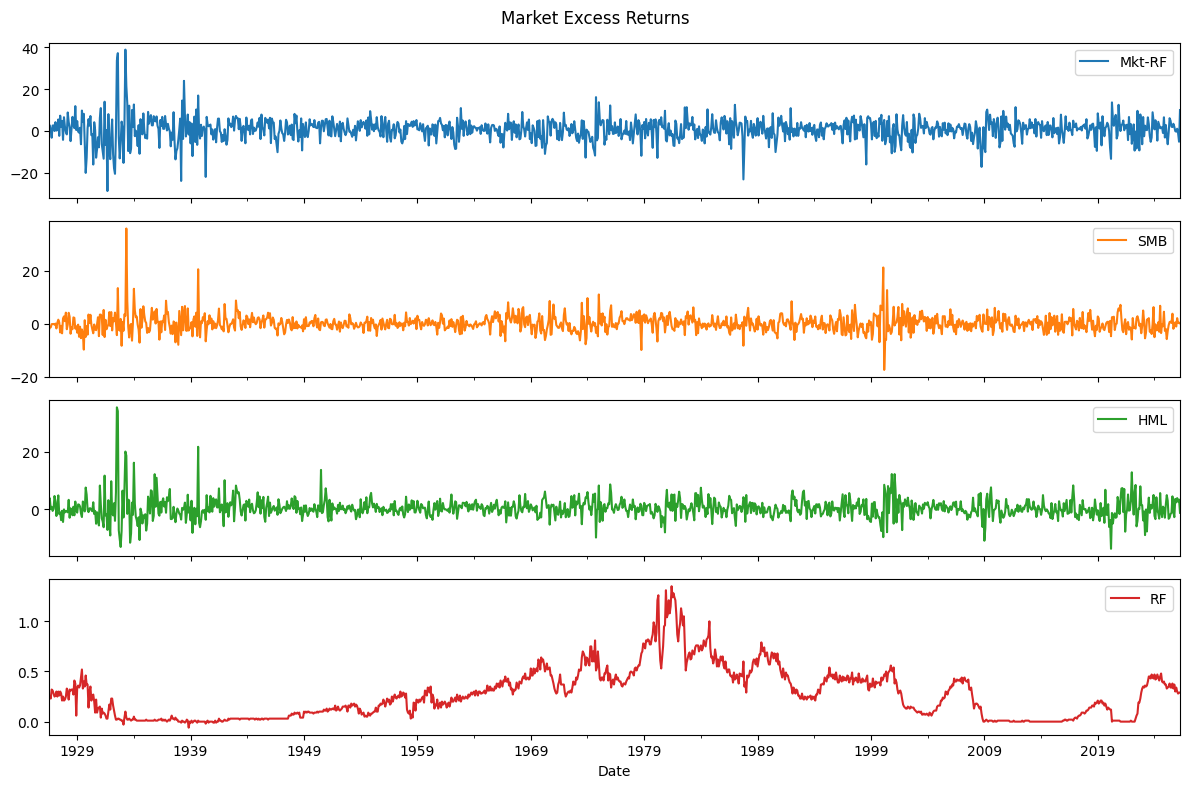

In [5]:
ax = df[['Mkt-RF', 'SMB', 'HML', 'RF']].plot(
    subplots=True,
    figsize=(12,8),
    layout=(4,1)
)

plt.suptitle("Market Excess Returns")
plt.tight_layout()
plt.show()

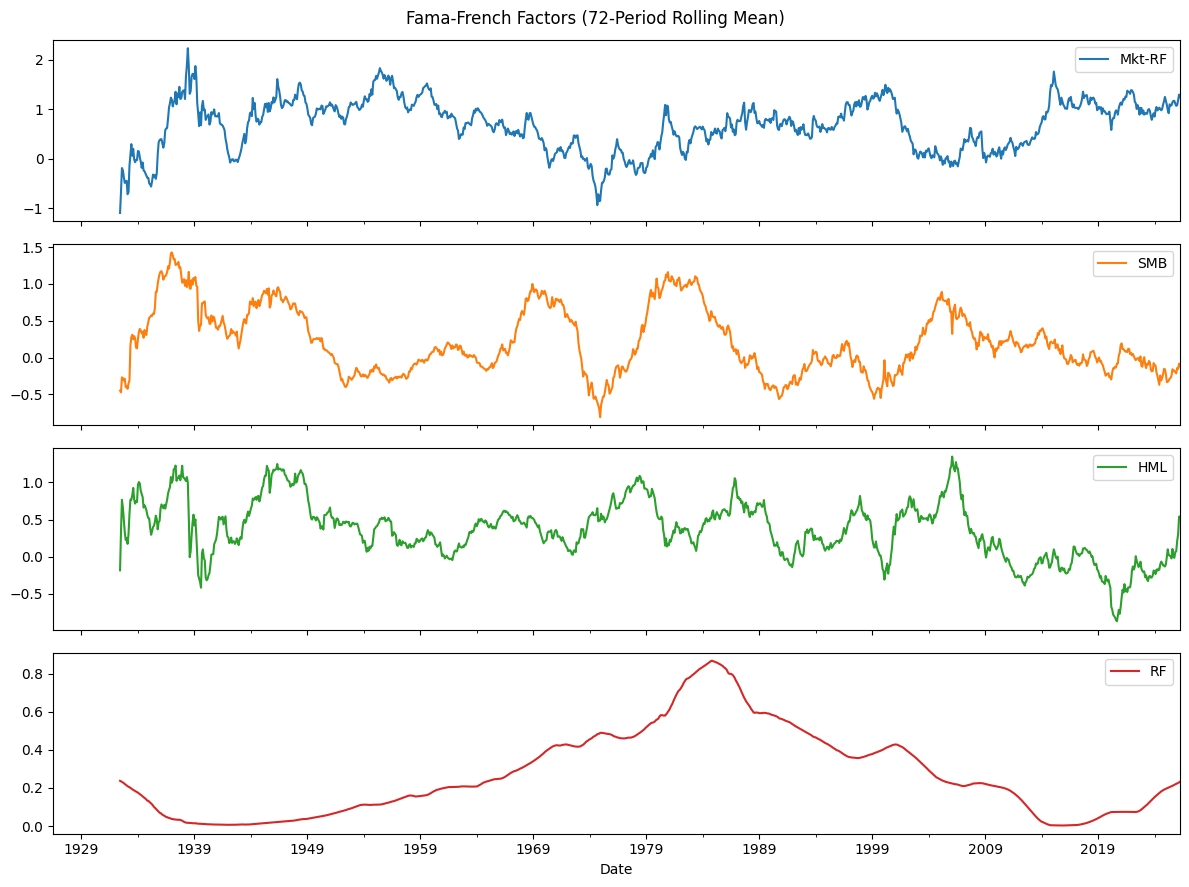

In [6]:
ax = df[['Mkt-RF', 'SMB', 'HML', 'RF']].rolling(72).mean().plot(
    subplots=True,
    figsize=(12,9),
    layout=(4,1),
    sharex=True
)

plt.suptitle("Fama-French Factors (72-Period Rolling Mean)")
plt.tight_layout()
plt.show()

In [16]:
start = '1926-01-01'
ff_mom = pdr.DataReader('F-F_Momentum_Factor', 'famafrench', start=start)[0]
ff_mom.index = ff_mom.index.to_timestamp()

/tmp/ipykernel_3794/2845685135.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_mom = pdr.DataReader('F-F_Momentum_Factor', 'famafrench', start=start)[0]
/tmp/ipykernel_3794/2845685135.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_mom = pdr.DataReader('F-F_Momentum_Factor', 'famafrench', start=start)[0]


array([<Axes: xlabel='Date'>], dtype=object)

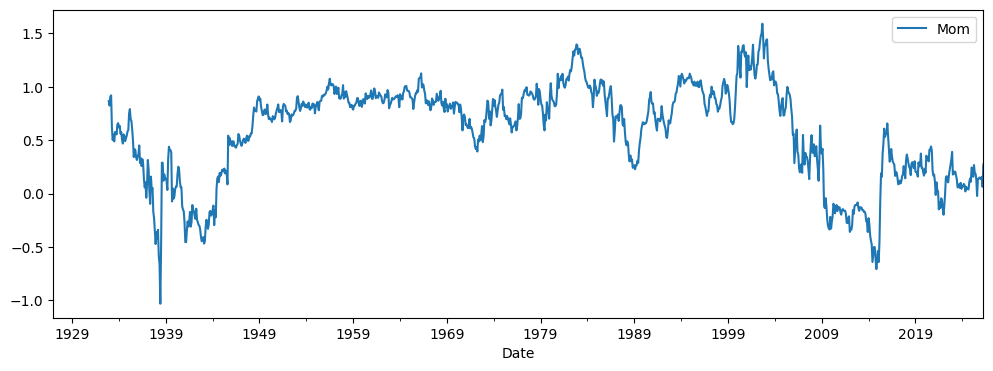

In [9]:
ff_mom.rolling(72).mean().plot(subplots=True,figsize=(12,4))

In [10]:
ffav_merged_df = pd.merge(ff[0], ff_mom, how='inner', left_index=True, right_index=True, sort=True, copy=True, indicator=True)

In [11]:
ffav_merged_df

,Mkt-RF,SMB,HML,RF,Mom,_merge
Date,,,,,,
1927-01-01,-0.05,-0.32,4.58,0.25,0.57,both
1927-02-01,4.17,0.07,2.72,0.26,-1.50,both
1927-03-01,0.14,-1.77,-2.38,0.30,3.52,both
1927-04-01,0.47,0.39,0.65,0.25,4.36,both
1927-05-01,5.45,1.55,4.80,0.30,2.78,both
...,...,...,...,...,...,...
2025-12-01,-0.36,-1.03,2.36,0.34,-2.33,both
2026-01-01,1.03,2.12,3.86,0.30,4.98,both
2026-02-01,-1.17,0.24,2.65,0.28,1.27,both


In [14]:
import yfinance as yf
AAPL_df = yf.download('AAPL', start=start)['Close'].resample('ME').ffill().pct_change()

/tmp/ipykernel_3794/3571926720.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  AAPL_df = yf.download('AAPL', start=start)['Close'].resample('ME').ffill().pct_change()
[*********************100%***********************]  1 of 1 completed


In [15]:
AAPL_df.index.dtype
ffav_merged_df.index.dtype

dtype('<M8[ns]')

In [17]:
AAPL_df['str_date'] = AAPL_df.index.astype(str)
AAPL_df['dt_date'] = pd.to_datetime(AAPL_df['str_date']).dt.strftime('%Y-%m')


In [18]:
AAPL_df.dt_date.dtype

dtype('O')

In [19]:
ffav_merged_df['str_date'] = ffav_merged_df.index.astype(str)
ffav_merged_df['dt_date'] = pd.to_datetime(ffav_merged_df['str_date']).dt.strftime('%Y-%m')

In [20]:
AAPL_ffav_merge_df = pd.merge(AAPL_df, ffav_merged_df, how='inner',on= 'dt_date', sort=True, copy=True, indicator='AAPL_FF_merge_indicator', validate='one_to_one')

In [25]:
AAPL_ffav_merge_df.drop(columns=['str_date_x','str_date_y'],inplace = True, errors='ignore')
AAPL_ffav_merge_df

,AAPL,dt_date,Mkt-RF,SMB,HML,RF,Mom,_merge,AAPL_FF_merge_indicator
0,NaN,1980-12,-4.46,-0.28,2.80,1.31,-6.71,both,both
1,-0.172163,1981-01,-5.06,2.91,6.74,1.04,-7.82,both,both
2,-0.061943,1981-02,0.61,-0.47,0.97,1.07,-1.35,both,both
3,-0.075475,1981-03,3.67,3.34,0.61,1.21,0.82,both,both
4,0.158162,1981-04,-2.16,4.50,2.28,1.08,-1.08,both,both
...,...,...,...,...,...,...,...,...,...
540,-0.025067,2025-12,-0.36,-1.03,2.36,0.34,-2.33,both,both
541,-0.045538,2026-01,1.03,2.12,3.86,0.30,4.98,both,both
542,0.019066,2026-02,-1.17,0.24,2.65,0.28,1.27,both,both
543,-0.039329,2026-03,-5.18,0.44,3.35,0.29,1.54,both,both


In [26]:
AAPL_ffav_merge_df['AAPL_RF'] = AAPL_ffav_merge_df['AAPL']*100 - AAPL_ffav_merge_df['RF']
AAPL_ffav_merge_df

,AAPL,dt_date,Mkt-RF,SMB,HML,RF,Mom,_merge,AAPL_FF_merge_indicator,AAPL_RF
0,NaN,1980-12,-4.46,-0.28,2.80,1.31,-6.71,both,both,NaN
1,-0.172163,1981-01,-5.06,2.91,6.74,1.04,-7.82,both,both,-18.256275
2,-0.061943,1981-02,0.61,-0.47,0.97,1.07,-1.35,both,both,-7.264310
3,-0.075475,1981-03,3.67,3.34,0.61,1.21,0.82,both,both,-8.757495
4,0.158162,1981-04,-2.16,4.50,2.28,1.08,-1.08,both,both,14.736226
...,...,...,...,...,...,...,...,...,...,...
540,-0.025067,2025-12,-0.36,-1.03,2.36,0.34,-2.33,both,both,-2.846729
541,-0.045538,2026-01,1.03,2.12,3.86,0.30,4.98,both,both,-4.853809
542,0.019066,2026-02,-1.17,0.24,2.65,0.28,1.27,both,both,1.626580
543,-0.039329,2026-03,-5.18,0.44,3.35,0.29,1.54,both,both,-4.222929


In [27]:
AAPL_ffav_merge_df.dropna(axis=0,inplace=True)

In [28]:
from statsmodels.api import OLS
results = OLS(AAPL_ffav_merge_df['AAPL_RF'], AAPL_ffav_merge_df[['Mkt-RF', 'SMB', 'HML', 'Mom']],missing='drop').fit()

In [29]:
import statsmodels.tools
AAPL_ffav_merge_df_c = statsmodels.tools.add_constant(AAPL_ffav_merge_df,prepend=True)

In [30]:
results = OLS(AAPL_ffav_merge_df_c['AAPL_RF'], AAPL_ffav_merge_df_c[['const','Mkt-RF', 'SMB', 'HML', 'Mom']],missing='drop').fit()
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                AAPL_RF   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     52.94
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.26e-37
Time:                        19:47:21   Log-Likelihood:                -2057.0
No. Observations:                 544   AIC:                             4124.
Df Residuals:                     539   BIC:                             4145.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3656      0.474      2.881      0.004       0.434       2.297
Mkt-RF         1.1739      0.110     10.663      0.000       0.958       1.390
SMB            0.2408      0.161      1.496      0.135      -0.075       0.557
HML           -0.8595      0.156     -5.492      0.000      -1.167      -0.552
Mom           -0.1272      0.111     -1.146      0.252      -0.345       0.091
==============================================================================
Omnibus:                       17.914   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.433
Skew:                          -0.041   Prob(JB):                     1.66e-09
Kurtosis:                       4.333   Cond. No.                         5.10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Residual Analysis

Visualizing the residuals is a crucial step in validating a regression model. We'll generate a few plots to check key assumptions:

1.  **Histogram of Residuals**: To visually inspect if the residuals are approximately normally distributed.
2.  **Normal Q-Q Plot**: A more formal way to check for normality, comparing residual quantiles against theoretical normal quantiles.
3.  **Residuals vs. Fitted Values Plot**: To check for homoscedasticity (constant variance of residuals) and linearity. Ideally, residuals should be randomly scattered around zero with no discernible pattern.

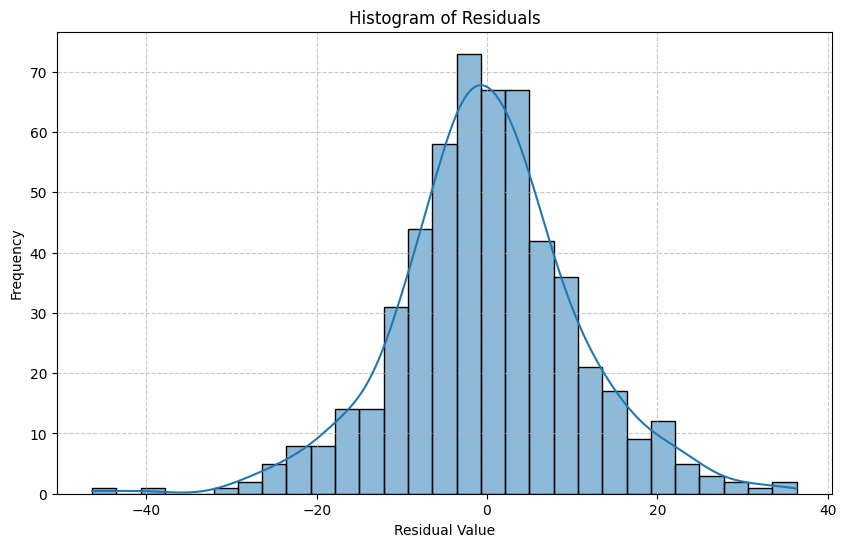

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the OLS results
residuals = results.resid

# Plot 1: Histogram of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<Figure size 1000x600 with 0 Axes>

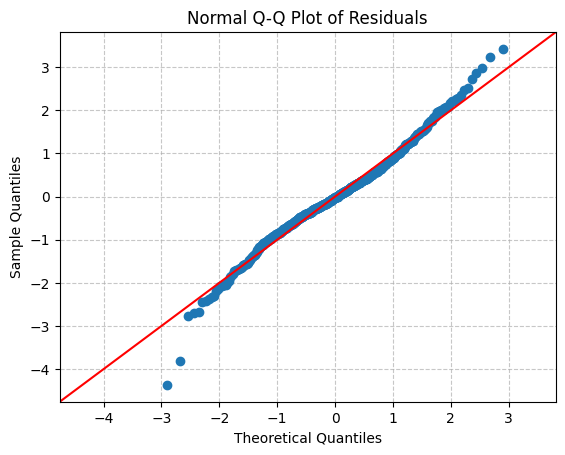

In [32]:
# Plot 2: Normal Q-Q Plot of Residuals
plt.figure(figsize=(10, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Normal Q-Q Plot of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

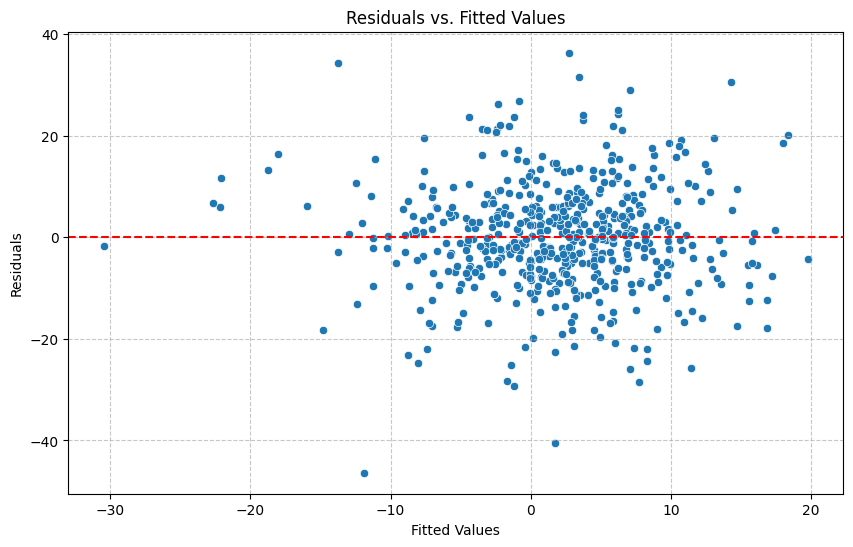

In [33]:
# Plot 3: Residuals vs. Fitted Values
fitted_values = results.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [34]:
# Export the DataFrame to a CSV file
AAPL_ffav_merge_df.to_csv('AAPL_ffav_merge_df.csv', index=False)
print('DataFrame exported successfully to AAPL_ffav_merge_df.csv')

DataFrame exported successfully to AAPL_ffav_merge_df.csv


In [35]:
# Export the DataFrame to a CSV file
AAPL_ffav_merge_df_c.to_csv('AAPL_ffav_merge_df_c.csv', index=False)
print('DataFrame exported successfully to AAPL_ffav_merge_df_c.csv')

DataFrame exported successfully to AAPL_ffav_merge_df_c.csv
